# Avance 4. Modelos alternativos con dataset anual AlphaEarth

**Proyecto:** Monitoreo de estrés hídrico en huertos de aguacate con embeddings satelitales AlphaEarth y etiquetas anuales de estrés.  
**Equipo:** 19  
**Entregable:** `Avance4.Equipo19`

Esta libreta responde a los requerimientos del Avance 4:

1. Construir al menos 6 modelos individuales, no ensambles, con algoritmos variados.
2. Comparar su desempeño con una tabla que incluya `F1 macro`, métricas complementarias y tiempo de entrenamiento.
3. Seleccionar los dos mejores modelos.
4. Ajustar hiperparámetros de esos dos modelos.
5. Elegir un modelo individual final con justificación técnica y de negocio.

El experimento principal usa el dataset anual `alphaearth_dataset_2018_2025_with_annual_labels.csv`. Cada observación representa una parcela en un año, con 512 variables derivadas de los 64 canales AlphaEarth y una etiqueta anual de estrés. Para mantener una evaluación limpia, los modelos usan solo variables AlphaEarth como predictores; las variables NDVI/NDMI anuales se reservan para auditoría de etiquetas y contexto descriptivo.


## 1. Verificación de dependencias

Ejecuta esta celda si el kernel no tiene instaladas las librerías necesarias. Usa el mismo Python del kernel activo para instalar paquetes faltantes.


In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tifffile": "tifffile",
    "imagecodecs": "imagecodecs",
}

missing_packages = [
    pip_name
    for module_name, pip_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Instalando paquetes faltantes en el kernel activo:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Todas las dependencias principales están disponibles.")


Todas las dependencias principales están disponibles.


## 2. Imports y configuración

La libreta usa dependencias ya presentes en el proyecto para comparar modelos individuales sobre datos tabulares AlphaEarth. Se fija una semilla para reproducibilidad y se definen rutas portables dentro de la estructura del repositorio.


In [2]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV, StratifiedKFold, TimeSeriesSplit, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DATASETS_DIR = PROJECT_ROOT.parent / "Datasets"
ANNUAL_DATASET_PATH = DATASETS_DIR / "alphaearth_dataset_2018_2025_with_annual_labels.csv"

# Respaldo local previo, por si el dataset anual no está disponible.
LEGACY_DATASET_PATH = NOTEBOOK_DIR / "df_fe_avance2.csv"
MONTHLY_PATH = NOTEBOOK_DIR / "data" / "csv" / "aguacates_jalisco_monthly_indices_2023_2026.csv"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Dataset anual AlphaEarth:", ANNUAL_DATASET_PATH)
print("Dataset legacy:", LEGACY_DATASET_PATH)


PROJECT_ROOT: c:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI
Dataset anual AlphaEarth: c:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Datasets\alphaearth_dataset_2018_2025_with_annual_labels.csv
Dataset legacy: c:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Avocado AI\notebooks\df_fe_avance2.csv


## 3. Carga del dataset anual AlphaEarth

El dataset principal contiene aproximadamente 800 observaciones: 100 parcelas observadas entre 2018 y 2025. La variable objetivo es `stress_label_annual`, con su descripción textual en `stress_class_annual`.

Se usan como predictores únicamente las variables AlphaEarth `A00_*` a `A63_*`. Las columnas anuales de NDVI/NDMI se conservan para revisar coherencia de etiquetas, pero no se incluyen en `X` para evitar fuga conceptual: la etiqueta anual fue construida a partir de señales de estrés relacionadas con NDMI.


In [3]:
def build_minimal_dataset_from_monthly(path: Path) -> pd.DataFrame:
    monthly = pd.read_csv(path)
    monthly["date"] = pd.to_datetime(monthly["date"])
    monthly = monthly.sort_values(["name", "date"]).reset_index(drop=True)
    q1, q2 = monthly["NDMI"].quantile([0.25, 0.50])
    monthly["stress_label_annual"] = np.select([monthly["NDMI"] <= q1, monthly["NDMI"] <= q2], [2, 1], default=0).astype(int)
    monthly["stress_class_annual"] = monthly["stress_label_annual"].map({
        0: "no_relative_stress",
        1: "moderate_possible_stress",
        2: "severe_possible_stress",
    })
    annual = monthly.groupby(["name", "year"], as_index=False).agg(
        lat=("lat", "first"),
        lon=("lon", "first"),
        stress_label_annual=("stress_label_annual", "max"),
        stress_class_annual=("stress_class_annual", "last"),
        months_observed=("month", "nunique"),
        NDVI_mean_year=("NDVI", "mean"),
        NDVI_min_year=("NDVI", "min"),
        NDVI_max_year=("NDVI", "max"),
        NDMI_mean_year=("NDMI", "mean"),
        NDMI_min_year=("NDMI", "min"),
        NDMI_max_year=("NDMI", "max"),
    )
    return annual


if ANNUAL_DATASET_PATH.exists():
    model_df = pd.read_csv(ANNUAL_DATASET_PATH)
    dataset_version = "alphaearth_annual_2018_2025"
elif LEGACY_DATASET_PATH.exists():
    model_df = pd.read_csv(LEGACY_DATASET_PATH)
    model_df = model_df.rename(columns={"stress_label": "stress_label_annual", "stress_class": "stress_class_annual"})
    dataset_version = "legacy_monthly_as_backup"
elif MONTHLY_PATH.exists():
    model_df = build_minimal_dataset_from_monthly(MONTHLY_PATH)
    dataset_version = "monthly_backup_aggregated"
else:
    raise FileNotFoundError("No se encontró ningún dataset compatible.")

if "name" not in model_df.columns and "parcela" in model_df.columns:
    model_df = model_df.rename(columns={"parcela": "name"})

target_col = "stress_label_annual"
target_name_col = "stress_class_annual"
required_cols = {"name", "year", target_col}
missing = required_cols - set(model_df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

model_df["name"] = model_df["name"].astype(str)
model_df["year"] = model_df["year"].astype(int)
model_df[target_col] = model_df[target_col].astype(int)

label_map = (
    model_df[[target_col, target_name_col]]
    .drop_duplicates()
    .sort_values(target_col)
    .set_index(target_col)[target_name_col]
    .to_dict()
    if target_name_col in model_df.columns
    else {0: "sin estrés relativo", 1: "estrés moderado posible", 2: "estrés severo posible"}
)

alpha_feature_cols = [
    c for c in model_df.columns
    if c.startswith("A") and pd.api.types.is_numeric_dtype(model_df[c])
]

if not alpha_feature_cols:
    alpha_feature_cols = [
        c for c in model_df.select_dtypes(include=[np.number]).columns
        if c not in {target_col, "year"}
    ]

print("Versión de dataset:", dataset_version)
print("Forma:", model_df.shape)
print("Parcelas únicas:", model_df["name"].nunique())
print("Años:", sorted(model_df["year"].unique()))
print("Features AlphaEarth:", len(alpha_feature_cols))
display(model_df.head())


Versión de dataset: alphaearth_annual_2018_2025
Forma: (800, 528)
Parcelas únicas: 100
Años: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Features AlphaEarth: 512


,name,year,lat,lon,patch_path,A00_valid_ratio,A00_mean,A00_std,A00_min,A00_max,A00_p25,A00_p50,A00_p75,A01_valid_ratio,A01_mean,A01_std,A01_min,A01_max,A01_p25,A01_p50,A01_p75,A02_valid_ratio,A02_mean,A02_std,A02_min,A02_max,A02_p25,A02_p50,A02_p75,A03_valid_ratio,A03_mean,A03_std,A03_min,A03_max,A03_p25,A03_p50,A03_p75,A04_valid_ratio,A04_mean,A04_std,A04_min,A04_max,A04_p25,A04_p50,A04_p75,A05_valid_ratio,A05_mean,A05_std,A05_min,A05_max,A05_p25,A05_p50,A05_p75,A06_valid_ratio,A06_mean,A06_std,A06_min,A06_max,A06_p25,A06_p50,A06_p75,A07_valid_ratio,A07_mean,A07_std,A07_min,A07_max,A07_p25,A07_p50,A07_p75,A08_valid_ratio,A08_mean,A08_std,A08_min,A08_max,A08_p25,A08_p50,A08_p75,A09_valid_ratio,A09_mean,A09_std,...,A55_min,A55_max,A55_p25,A55_p50,A55_p75,A56_valid_ratio,A56_mean,A56_std,A56_min,A56_max,A56_p25,A56_p50,A56_p75,A57_valid_ratio,A57_mean,A57_std,A57_min,A57_max,A57_p25,A57_p50,A57_p75,A58_valid_ratio,A58_mean,A58_std,A58_min,A58_max,A58_p25,A58_p50,A58_p75,A59_valid_ratio,A59_mean,A59_std,A59_min,A59_max,A59_p25,A59_p50,A59_p75,A60_valid_ratio,A60_mean,A60_std,A60_min,A60_max,A60_p25,A60_p50,A60_p75,A61_valid_ratio,A61_mean,A61_std,A61_min,A61_max,A61_p25,A61_p50,A61_p75,A62_valid_ratio,A62_mean,A62_std,A62_min,A62_max,A62_p25,A62_p50,A62_p75,A63_valid_ratio,A63_mean,A63_std,A63_min,A63_max,A63_p25,A63_p50,A63_p75,stress_class_annual,stress_label_annual,months_observed,NDVI_mean_year,NDVI_min_year,NDVI_max_year,NDMI_mean_year,NDMI_min_year,NDMI_max_year,low_ndmi_months,severe_months
0,H1,2018,19.663164,-103.48747,C:\Users\omarh\Desktop\Maestria\avocado_projec...,0.760349,0.021408,0.045488,-0.062991,0.153787,-0.017270,0.012057,0.055363,0.760349,-0.168032,0.040815,-0.318893,-0.051734,-0.192910,-0.166336,-0.141730,0.760349,0.046236,0.039845,-0.055363,0.206936,0.017778,0.044844,0.071111,0.760349,0.050542,0.038100,-0.048228,0.179377,0.024606,0.044844,0.071111,0.760349,-0.032386,0.027558,-0.093564,0.038447,-0.051734,-0.035433,-0.012057,0.760349,-0.161124,0.047418,-0.292872,-0.008858,-0.192910,-0.153787,-0.124567,0.760349,-0.008248,0.053391,-0.108512,0.153787,-0.044844,-0.022207,0.015748,0.760349,0.017818,0.070654,-0.160000,0.141730,-0.044844,0.038447,0.079723,0.760349,-0.141502,0.084646,-0.374256,0.003937,-0.206936,-0.130165,-0.066990,0.760349,-0.017274,0.074206,...,-0.093564,0.179377,0.035433,0.071111,0.113741,0.760349,-0.010354,0.040964,-0.141730,0.119093,-0.038447,-0.015748,0.017778,0.760349,0.025227,0.073265,-0.153787,0.192910,-0.027128,0.013841,0.079723,0.760349,-0.241765,0.048478,-0.393695,-0.044844,-0.276140,-0.236463,-0.206936,0.760349,-0.323939,0.078370,-0.444444,-0.071111,-0.383914,-0.346021,-0.278216,0.760349,0.069631,0.044223,-0.088827,0.192910,0.051734,0.071111,0.093564,0.760349,-0.125142,0.033183,-0.206936,-0.035433,-0.153787,-0.119093,-0.098424,0.760349,0.014338,0.068922,-0.179377,0.130165,-0.024606,0.027128,0.066990,0.760349,-0.034496,0.044520,-0.166336,0.075356,-0.066990,-0.035433,-0.003937,moderate_possible_stress,1,7,0.282920,0.183223,0.424012,-0.053236,-0.132137,0.059453,4,0
1,H1,2019,19.663164,-103.48747,C:\Users\omarh\Desktop\Maestria\avocado_projec...,0.760349,0.025780,0.038776,-0.084214,0.147697,-0.002215,0.019931,0.055363,0.760349,-0.166431,0.046446,-0.310096,-0.044844,-0.192910,-0.166336,-0.135886,0.760349,0.063009,0.036066,-0.035433,0.199862,0.038447,0.062991,0.088827,0.760349,0.031531,0.044507,-0.079723,0.166336,0.003014,0.022207,0.055363,0.760349,-0.047213,0.022955,-0.119093,0.022207,-0.062991,-0.044844,-0.032541,0.760349,-0.169339,0.049761,-0.336855,-0.019931,-0.192910,-0.160000,-0.135886,0.760349,0.014887,0.041264,-0.103406,0.147697,-0.013841,0.011226,0.035433,0.760349,0.008275,0.060765,-0.135886,0.124567,-0.038447,0.022207,0.059116,0.760349,-0.138227,0.084787,-0.374256,0.019931,-0.199862,-0.124567,-0.066990,0.760349,-0.024580,0.078019,...,-0.079723,0.166336,0.024606,0.062991,0.108512,0.760349,-0.026269,0.034256,-0.124567,0.093564,-0.048228,-0.032541,-0.010396,0.760349,0.028195,0.064256,-0.

## 4. Diagnóstico de clases y cobertura temporal

La métrica principal será `F1 macro`, porque da el mismo peso a cada clase. También se reportan `balanced_accuracy`, `precision_macro`, `recall_macro`, `f1_weighted`, `accuracy` y `recall_severo`.

El dataset anual está mucho más balanceado que el dataset mensual previo, lo cual reduce la necesidad de downsampling. Aun así, varios modelos usan `class_weight="balanced"` para mantener sensibilidad ante diferencias por clase.


,clase,conteo,porcentaje
0,no_relative_stress,284,35.50
1,moderate_possible_stress,285,35.62
2,severe_possible_stress,231,28.88


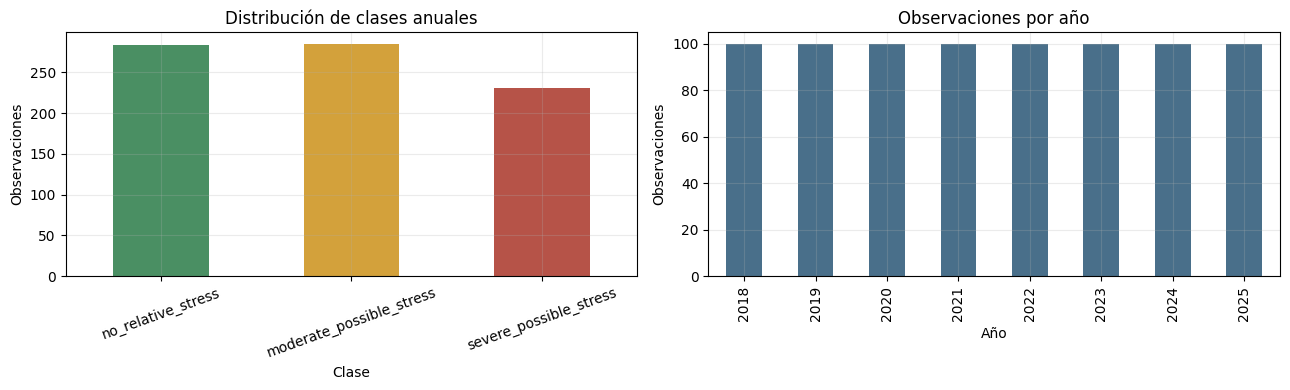

,months_observed,NDVI_mean_year,NDVI_min_year,NDMI_mean_year,NDMI_min_year,low_ndmi_months,severe_months
stress_label_annual,,,,,,,
no_relative_stress,11.736,0.566,0.413,0.121,0.032,0.000,0.000
moderate_possible_stress,11.316,0.465,0.291,0.029,-0.096,3.302,0.000
severe_possible_stress,11.004,0.429,0.243,-0.044,-0.195,5.775,3.939


In [4]:
class_counts = model_df[target_col].value_counts().sort_index()
class_summary = pd.DataFrame({
    "clase": class_counts.index.map(label_map),
    "conteo": class_counts.values,
    "porcentaje": (class_counts.values / class_counts.sum() * 100).round(2),
})
display(class_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
class_counts.rename(index=label_map).plot(kind="bar", ax=axes[0], color=["#4a8f63", "#d3a13b", "#b65348"])
axes[0].set_title("Distribución de clases anuales")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Observaciones")
axes[0].tick_params(axis="x", rotation=20)

model_df["year"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#496f8a")
axes[1].set_title("Observaciones por año")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Observaciones")
plt.tight_layout()
plt.show()

context_cols = [c for c in ["months_observed", "NDVI_mean_year", "NDVI_min_year", "NDMI_mean_year", "NDMI_min_year", "low_ndmi_months", "severe_months"] if c in model_df.columns]
if context_cols:
    display(model_df.groupby(target_col)[context_cols].mean().rename(index=label_map).round(3))


## 5. Selección de predictores AlphaEarth

El experimento principal se mantiene como `AlphaEarth -> etiqueta anual`. Por ello, el conjunto `X` incluye las 512 variables `A00_*...A63_*` y excluye variables usadas para construir o auditar la etiqueta, como NDVI/NDMI anual, conteos de meses de estrés y nombres de clase.

Esta separación permite medir si los embeddings AlphaEarth capturan señales útiles para clasificar estrés hídrico anual sin usar directamente los índices espectrales que originaron la etiqueta.


In [5]:
leakage_or_context_cols = {
    "lat", "lon", "year", target_col, target_name_col,
    "months_observed", "NDVI_mean_year", "NDVI_min_year", "NDVI_max_year",
    "NDMI_mean_year", "NDMI_min_year", "NDMI_max_year",
    "low_ndmi_months", "severe_months",
}

feature_cols = [c for c in alpha_feature_cols if c not in leakage_or_context_cols]
X = model_df[feature_cols].copy()
y = model_df[target_col].astype(int).copy()
groups = model_df["name"].astype(str).copy()
years = model_df["year"].astype(int).copy()

print("Features usadas:", len(feature_cols))
print("Primeras 20:", feature_cols[:20])
print("Últimas 20:", feature_cols[-20:])
print("X:", X.shape, "y:", y.shape)


Features usadas: 512
Primeras 20: ['A00_valid_ratio', 'A00_mean', 'A00_std', 'A00_min', 'A00_max', 'A00_p25', 'A00_p50', 'A00_p75', 'A01_valid_ratio', 'A01_mean', 'A01_std', 'A01_min', 'A01_max', 'A01_p25', 'A01_p50', 'A01_p75', 'A02_valid_ratio', 'A02_mean', 'A02_std', 'A02_min']
Últimas 20: ['A61_max', 'A61_p25', 'A61_p50', 'A61_p75', 'A62_valid_ratio', 'A62_mean', 'A62_std', 'A62_min', 'A62_max', 'A62_p25', 'A62_p50', 'A62_p75', 'A63_valid_ratio', 'A63_mean', 'A63_std', 'A63_min', 'A63_max', 'A63_p25', 'A63_p50', 'A63_p75']
X: (800, 512) y: (800,)


## 6. Particiones de evaluación

Se mantienen dos lecturas complementarias:

1. **Split por parcela 75/25** con `GroupShuffleSplit`, para que una misma parcela no aparezca simultáneamente en entrenamiento y prueba.
2. **GroupKFold por parcela** para medir generalización a parcelas no vistas durante la validación cruzada.

También se deja preparada una evaluación temporal opcional: entrenar con años antiguos y probar contra años recientes. Esta lectura es útil porque el dataset cubre 2018-2025.


In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Train:", X_train.shape, "parcelas:", g_train.nunique())
print("Test :", X_test.shape, "parcelas:", g_test.nunique())
print("Intersección parcelas train/test:", len(set(g_train) & set(g_test)))

display(pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index().rename(index=label_map),
    "test": y_test.value_counts(normalize=True).sort_index().rename(index=label_map),
}).fillna(0).round(3))

temporal_train_mask = years <= 2023
temporal_test_mask = years >= 2024
print("Split temporal opcional 2018-2023 -> 2024-2025:")
print("Train temporal:", temporal_train_mask.sum(), "Test temporal:", temporal_test_mask.sum())


Train: (600, 512) parcelas: 75
Test : (200, 512) parcelas: 25
Intersección parcelas train/test: 0


,train,test
stress_label_annual,,
no_relative_stress,0.333,0.42
moderate_possible_stress,0.368,0.32
severe_possible_stress,0.298,0.26


Split temporal opcional 2018-2023 -> 2024-2025:
Train temporal: 600 Test temporal: 200


## 7. Preparación de variables

La matriz de modelado queda a nivel parcela-año. La separación por grupos evita que una misma parcela aparezca simultáneamente en entrenamiento y prueba.


In [7]:
print("Dataset usado:", dataset_version)
print("Unidad de observación: parcela-año")
print("Número de features:", len(feature_cols))
print("Número de clases:", y.nunique())
print("Parcelas:", groups.nunique())
print("Años:", years.min(), "-", years.max())


Dataset usado: alphaearth_annual_2018_2025
Unidad de observación: parcela-año
Número de features: 512
Número de clases: 3
Parcelas: 100
Años: 2018 - 2025


## 8. Definición de modelos individuales

Se comparan siete modelos individuales, no ensambles: regresión logística, SVM lineal, SVM RBF, KNN, árbol de decisión, Naive Bayes gaussiano y MLP. También se incluye un `DummyClassifier` como referencia mínima, pero no cuenta como candidato final.


In [8]:
def dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else X


preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
dense_transformer = FunctionTransformer(dense_array, accept_sparse=True)

candidate_models = {
    "logistic_regression_balanced": LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", multi_class="auto", random_state=SEED),
    "linear_svm_balanced": LinearSVC(class_weight="balanced", C=1.0, random_state=SEED, max_iter=10000),
    "rbf_svm_balanced": SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced", random_state=SEED),
    "knn_distance": KNeighborsClassifier(n_neighbors=9, weights="distance"),
    "decision_tree_balanced": DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, class_weight="balanced", random_state=SEED),
    "gaussian_naive_bayes": GaussianNB(),
    "mlp_neural_network": MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, learning_rate_init=1e-3, max_iter=600, early_stopping=True, random_state=SEED),
}

baseline_models = {"dummy_stratified": DummyClassifier(strategy="stratified", random_state=SEED)}


## 9. Entrenamiento y comparación inicial

La tabla se ordena por `f1_macro`, métrica principal para evitar que la clase mayoritaria domine la evaluación. También se reporta tiempo de entrenamiento.


,modelo,accuracy,f1_macro,f1_weighted,balanced_accuracy,precision_macro,recall_macro,recall_severo,fit_seconds
0,logistic_regression_balanced,0.815,0.814382,0.816798,0.816239,0.814048,0.816239,0.865385,0.056571
1,rbf_svm_balanced,0.790,0.795336,0.796630,0.791667,0.825755,0.791667,0.750000,0.028873
2,mlp_neural_network,0.785,0.787484,0.791345,0.782776,0.813648,0.782776,0.730769,0.132917
3,linear_svm_balanced,0.720,0.723367,0.725498,0.724874,0.729723,0.724874,0.788462,0.410068
4,knn_distance,0.690,0.691546,0.696596,0.685325,0.731947,0.685325,0.596154,0.017277
5,decision_tree_balanced,0.695,0.682773,0.697094,0.673249,0.711174,0.673249,0.557692,0.098427
6,gaussian_naive_bayes,0.625,0.630034,0.631988,0.622692,0.681515,0.622692,0.538462,0.018232
7,dummy_stratified,0.330,0.316905,0.332846,0.317289,0.321548,0.317289,0.211538,0.018946


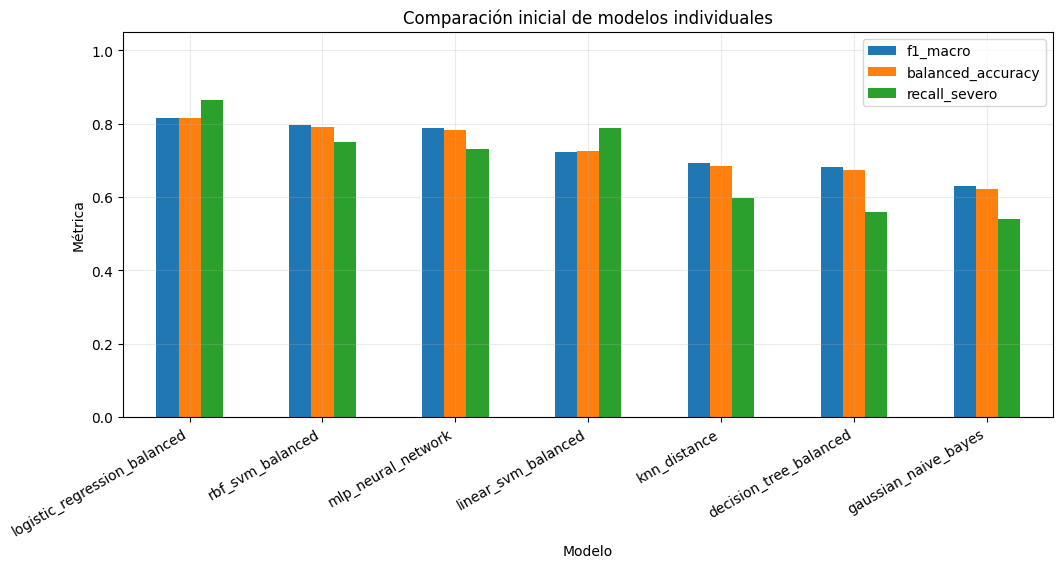

In [9]:
def make_pipeline(model):
    steps = [("preprocessor", preprocessor)]
    if isinstance(model, GaussianNB):
        steps.append(("dense", dense_transformer))
    steps.append(("clf", model))
    return Pipeline(steps)


def metric_row(model_name, y_true, y_pred, fit_seconds):
    return {
        "modelo": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_severo": recall_score(y_true, y_pred, labels=[2], average="macro", zero_division=0),
        "fit_seconds": fit_seconds,
    }


all_models = {**baseline_models, **candidate_models}
results = []
fitted_models = {}

for name, estimator in all_models.items():
    pipe = make_pipeline(estimator)
    start = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    pred = pipe.predict(X_test)
    results.append(metric_row(name, y_test, pred, fit_seconds))
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results_df)

ax = results_df[results_df["modelo"] != "dummy_stratified"].plot(
    x="modelo",
    y=["f1_macro", "balanced_accuracy", "recall_severo"],
    kind="bar",
    figsize=(12, 5),
)
ax.set_ylim(0, 1.05)
ax.set_title("Comparación inicial de modelos individuales")
ax.set_xlabel("Modelo")
ax.set_ylabel("Métrica")
plt.xticks(rotation=30, ha="right")
plt.show()


## 10. Validación cruzada por parcela

Para los modelos candidatos se calcula validación cruzada con `GroupKFold`. Esta es la validación más estricta del notebook porque estima desempeño sobre parcelas no vistas.


In [10]:
n_splits = min(5, groups.nunique())
cv = GroupKFold(n_splits=n_splits)
scoring = {
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "recall_severo": make_scorer(recall_score, labels=[2], average="macro", zero_division=0),
}

cv_rows = []
for name, estimator in candidate_models.items():
    pipe = make_pipeline(estimator)
    start = time.perf_counter()
    scores = cross_validate(pipe, X, y, groups=groups, cv=cv, scoring=scoring, n_jobs=None, return_train_score=False)
    elapsed = time.perf_counter() - start
    cv_rows.append({
        "modelo": name,
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_recall_severo_mean": scores["test_recall_severo"].mean(),
        "cv_seconds": elapsed,
    })

cv_df = pd.DataFrame(cv_rows).sort_values("cv_f1_macro_mean", ascending=False).reset_index(drop=True)
display(cv_df)


,modelo,cv_f1_macro_mean,cv_f1_macro_std,cv_balanced_accuracy_mean,cv_recall_severo_mean,cv_seconds
0,logistic_regression_balanced,0.882174,0.027541,0.888180,0.934418,0.381861
1,rbf_svm_balanced,0.865774,0.031464,0.866989,0.883244,0.239356
2,mlp_neural_network,0.826378,0.025913,0.833776,0.857456,0.645810
3,linear_svm_balanced,0.807823,0.039350,0.817235,0.895326,2.071973
4,knn_distance,0.767126,0.056210,0.775279,0.763476,0.221215
5,decision_tree_balanced,0.757060,0.033423,0.758988,0.820653,0.549437
6,gaussian_naive_bayes,0.729814,0.035898,0.735525,0.768120,0.133125


## 11. Selección de los dos mejores modelos

Se seleccionan los dos modelos con mejor `F1 macro` en validación cruzada. Si hay empate o resultados muy similares, también se consideran estabilidad, tiempo e interpretabilidad.


In [11]:
top2_names = cv_df.head(2)["modelo"].tolist()
print("Dos mejores modelos para ajuste fino:", top2_names)

comparison_initial = results_df.merge(cv_df, on="modelo", how="left")
display(comparison_initial.sort_values("cv_f1_macro_mean", ascending=False))


Dos mejores modelos para ajuste fino: ['logistic_regression_balanced', 'rbf_svm_balanced']


,modelo,accuracy,f1_macro,f1_weighted,balanced_accuracy,precision_macro,recall_macro,recall_severo,fit_seconds,cv_f1_macro_mean,cv_f1_macro_std,cv_balanced_accuracy_mean,cv_recall_severo_mean,cv_seconds
0,logistic_regression_balanced,0.815,0.814382,0.816798,0.816239,0.814048,0.816239,0.865385,0.056571,0.882174,0.027541,0.888180,0.934418,0.381861
1,rbf_svm_balanced,0.790,0.795336,0.796630,0.791667,0.825755,0.791667,0.750000,0.028873,0.865774,0.031464,0.866989,0.883244,0.239356
2,mlp_neural_network,0.785,0.787484,0.791345,0.782776,0.813648,0.782776,0.730769,0.132917,0.826378,0.025913,0.833776,0.857456,0.645810
3,linear_svm_balanced,0.720,0.723367,0.725498,0.724874,0.729723,0.724874,0.788462,0.410068,0.807823,0.039350,0.817235,0.895326,2.071973
4,knn_distance,0.690,0.691546,0.696596,0.685325,0.731947,0.685325,0.596154,0.017277,0.767126,0.056210,0.775279,0.763476,0.221215
5,decision_tree_balanced,0.695,0.682773,0.697094,0.673249,0.711174,0.673249,0.557692,0.098427,0.757060,0.033423,0.758988,0.820653,0.549437
6,gaussian_naive_bayes,0.625,0.630034,0.631988,0.622692,0.681515,0.622692,0.538462,0.018232,0.729814,0.035898,0.735525,0.768120,0.133125
7,dummy_stratified,0.330,0.316905,0.332846,0.317289,0.321548,0.317289,0.211538,0.018946,NaN,NaN,NaN,NaN,NaN


## 12. Ajuste fino de hiperparámetros

Se aplica `GridSearchCV` solo a los dos mejores modelos individuales. El espacio de búsqueda se mantiene razonable para que la libreta sea ejecutable localmente y suficientemente profundo para comparar configuraciones relevantes.


In [12]:
param_grids = {
    "logistic_regression_balanced": {"clf__C": [0.01, 0.1, 1.0, 3.0, 10.0], "clf__solver": ["lbfgs"]},
    "linear_svm_balanced": {"clf__C": [0.01, 0.1, 1.0, 3.0, 10.0]},
    "rbf_svm_balanced": {"clf__C": [0.3, 1.0, 3.0, 10.0], "clf__gamma": ["scale", 0.01, 0.03, 0.1]},
    "knn_distance": {"clf__n_neighbors": [3, 5, 7, 9, 15, 21], "clf__weights": ["uniform", "distance"], "clf__p": [1, 2]},
    "decision_tree_balanced": {"clf__max_depth": [3, 5, 8, 12, None], "clf__min_samples_leaf": [3, 5, 10, 20], "clf__criterion": ["gini", "entropy"]},
    "gaussian_naive_bayes": {"clf__var_smoothing": np.logspace(-12, -7, 6)},
    "mlp_neural_network": {"clf__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)], "clf__alpha": [1e-4, 1e-3, 1e-2], "clf__learning_rate_init": [5e-4, 1e-3]},
}

tuned_rows = []
tuned_models = {}

for name in top2_names:
    pipe = make_pipeline(candidate_models[name])
    search = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring=make_scorer(f1_score, average="macro", zero_division=0),
        cv=cv,
        n_jobs=None,
        refit=True,
        return_train_score=True,
    )
    start = time.perf_counter()
    search.fit(X, y, groups=groups)
    elapsed = time.perf_counter() - start
    tuned_models[name + "_tuned"] = search.best_estimator_
    tuned_rows.append({
        "modelo": name + "_tuned",
        "modelo_base": name,
        "best_cv_f1_macro": search.best_score_,
        "fit_seconds": elapsed,
        "best_params": search.best_params_,
    })
    print("\nModelo:", name)
    print("Mejor F1 macro CV:", round(search.best_score_, 4))
    print("Mejores parámetros:", search.best_params_)

tuned_summary = pd.DataFrame(tuned_rows).sort_values("best_cv_f1_macro", ascending=False)
display(tuned_summary)



Modelo: logistic_regression_balanced
Mejor F1 macro CV: 0.8913
Mejores parámetros: {'clf__C': 0.1, 'clf__solver': 'lbfgs'}

Modelo: rbf_svm_balanced
Mejor F1 macro CV: 0.8745
Mejores parámetros: {'clf__C': 10.0, 'clf__gamma': 'scale'}


,modelo,modelo_base,best_cv_f1_macro,fit_seconds,best_params
0,logistic_regression_balanced_tuned,logistic_regression_balanced,0.891258,1.778958,"{'clf__C': 0.1, 'clf__solver': 'lbfgs'}"
1,rbf_svm_balanced_tuned,rbf_svm_balanced,0.874455,9.251205,"{'clf__C': 10.0, 'clf__gamma': 'scale'}"


## 13. Evaluación final de modelos ajustados en prueba

Aunque el ajuste se hace con validación cruzada, se conserva la partición de prueba por parcela para revisar reporte de clasificación y matriz de confusión.


,modelo,accuracy,f1_macro,f1_weighted,balanced_accuracy,precision_macro,recall_macro,recall_severo,fit_seconds
0,rbf_svm_balanced_tuned,0.81,0.813926,0.815810,0.811222,0.839996,0.811222,0.769231,0.029000
1,logistic_regression_balanced_tuned,0.79,0.797508,0.794621,0.797676,0.807594,0.797676,0.846154,0.057953


Modelo individual final: rbf_svm_balanced_tuned
                          precision    recall  f1-score   support

      no_relative_stress       0.94      0.77      0.85        84
moderate_possible_stress       0.65      0.89      0.75        64
  severe_possible_stress       0.93      0.77      0.84        52

                accuracy                           0.81       200
               macro avg       0.84      0.81      0.81       200
            weighted avg       0.84      0.81      0.82       200



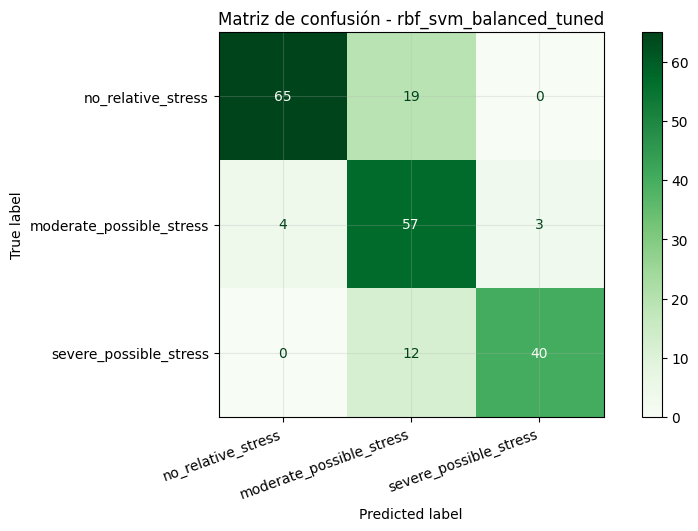

In [13]:
final_rows = []
for name, model in tuned_models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    pred = model.predict(X_test)
    final_rows.append(metric_row(name, y_test, pred, fit_seconds))

final_tuned_df = pd.DataFrame(final_rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(final_tuned_df)

final_model_name = final_tuned_df.iloc[0]["modelo"]
final_model = tuned_models[final_model_name]
final_pred = final_model.predict(X_test)

print("Modelo individual final:", final_model_name)
print(classification_report(
    y_test,
    final_pred,
    labels=sorted(y.unique()),
    target_names=[label_map.get(c, str(c)) for c in sorted(y.unique())],
    zero_division=0,
))

cm = confusion_matrix(y_test, final_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_map.get(c, str(c)) for c in sorted(y.unique())])
disp.plot(cmap="Greens", values_format="d")
plt.title(f"Matriz de confusión - {final_model_name}")
plt.xticks(rotation=20, ha="right")
plt.show()


## 14. Importancia de características

La interpretación depende del modelo final. Si el modelo expone coeficientes o importancias internas, se reportan. En todos los casos se calcula `permutation_importance` sobre la partición de prueba.


El modelo final no expone coeficientes/importancias internas directamente.


,feature,importance_mean,importance_std
141,A17_p25,0.013056,0.007911
143,A17_p75,0.012814,0.006866
308,A38_max,0.012583,0.003716
142,A17_p50,0.012233,0.006825
137,A17_mean,0.011907,0.008631
139,A17_min,0.011899,0.004159
386,A48_std,0.011775,0.002122
85,A10_p25,0.011196,0.005337
34,A04_std,0.011088,0.003008
388,A48_max,0.010843,0.004155


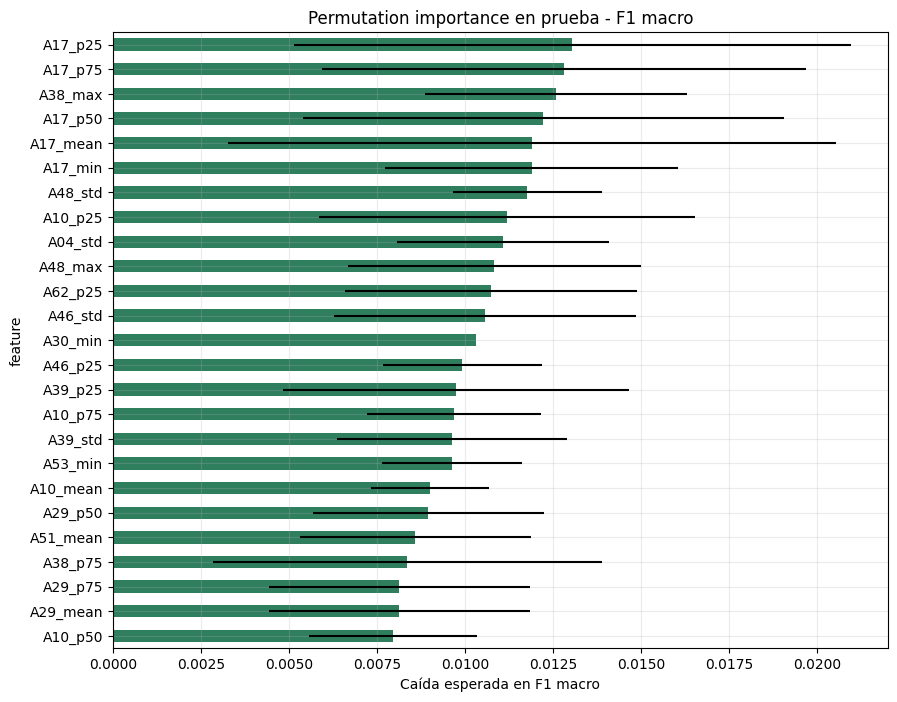

In [14]:
feature_names = np.array(feature_cols)
clf = final_model.named_steps["clf"]

if hasattr(clf, "coef_"):
    coef_importance = pd.Series(np.abs(clf.coef_).mean(axis=0), index=feature_names, name="coef_abs_promedio").sort_values(ascending=False)
    display(coef_importance.head(20).to_frame())
    ax = coef_importance.head(20).sort_values().plot(kind="barh", color="#496f8a")
    ax.set_title("Top 20 features por coeficiente absoluto promedio")
    ax.set_xlabel("Importancia")
    plt.show()
elif hasattr(clf, "feature_importances_"):
    tree_importance = pd.Series(clf.feature_importances_, index=feature_names, name="importance").sort_values(ascending=False)
    display(tree_importance.head(20).to_frame())
    ax = tree_importance.head(20).sort_values().plot(kind="barh", color="#496f8a")
    ax.set_title("Top 20 features por importancia interna")
    ax.set_xlabel("Importancia")
    plt.show()
else:
    print("El modelo final no expone coeficientes/importancias internas directamente.")

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring=make_scorer(f1_score, average="macro", zero_division=0),
    n_repeats=5,
    random_state=SEED,
)
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(25))
ax = perm_df.head(25).sort_values("importance_mean").plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    xerr="importance_std",
    color="#2f7f5f",
    legend=False,
    figsize=(10, 8),
)
ax.set_title("Permutation importance en prueba - F1 macro")
ax.set_xlabel("Caída esperada en F1 macro")
plt.show()


## 15. Análisis temporal y auditoría de etiquetas

El dataset anual permite revisar cómo evoluciona la distribución de clases por año y si las etiquetas mantienen coherencia con los indicadores anuales reservados para auditoría.


stress_label_annual,no_relative_stress,moderate_possible_stress,severe_possible_stress
year,,,
2018,15,39,46
2019,28,44,28
2020,26,39,35
2021,22,35,43
2022,38,35,27
2023,38,37,25
2024,60,27,13
2025,57,29,14


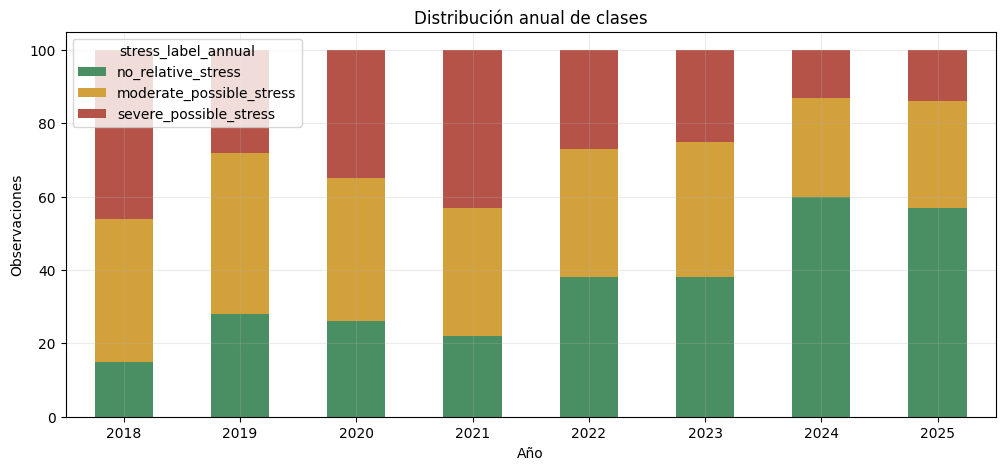

NDVI_mean_year        NDMI_mean_year         \
                                   mean median           mean median   
stress_label_annual                                                    
no_relative_stress                0.566  0.561          0.121  0.102   
moderate_possible_stress          0.465  0.470          0.029  0.032   
severe_possible_stress            0.429  0.434         -0.044 -0.040   

                         NDMI_min_year        low_ndmi_months         \
                                  mean median            mean median   
stress_label_annual                                                    
no_relative_stress               0.032  0.008           0.000    0.0   
moderate_possible_stress        -0.096 -0.095           3.302    3.0   
severe_possible_stress          -0.195 -0.187           5.775    6.0   

                         severe_months         
                                  mean median  
stress_label_annual                            
no_relative_stress               0.000    0.0  
moderate_possible_stress         0.000    0.0  
severe_possible_stress           3.939    4.0

In [15]:
year_class = (
    model_df.pivot_table(index="year", columns=target_col, values="name", aggfunc="count", fill_value=0)
    .rename(columns=label_map)
)
display(year_class)

ax = year_class.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#4a8f63", "#d3a13b", "#b65348"])
ax.set_title("Distribución anual de clases")
ax.set_xlabel("Año")
ax.set_ylabel("Observaciones")
plt.xticks(rotation=0)
plt.show()

audit_cols = [c for c in ["NDVI_mean_year", "NDMI_mean_year", "NDMI_min_year", "low_ndmi_months", "severe_months"] if c in model_df.columns]
if audit_cols:
    display(model_df.groupby(target_col)[audit_cols].agg(["mean", "median"]).rename(index=label_map).round(3))


## 16. CNN sobre parches AlphaEarth `HxWx64`

Esta sección incluye un modelo convolucional ligero que usa directamente los parches AlphaEarth, no solo sus estadísticos tabulares. El modelo se considera **experimental y complementario**: sirve para atender el enfoque espacial de AlphaEarth, pero los modelos individuales tabulares siguen siendo la base comparativa principal del Avance 4.

Para ejecutar esta sección se requiere `tensorflow`. Si no está instalado, la celda mostrará el comando de instalación y omitirá el entrenamiento sin romper la ejecución secuencial.


In [16]:
RUN_OPTIONAL_CNN = True
CNN_RANDOM_STATE = 42
PATCH_TARGET_SIZE = (32, 32)
CNN_EPOCHS = 15
CNN_BATCH_SIZE = 16

try:
    import tensorflow as tf
    from tensorflow.keras import callbacks, layers, models, regularizers
    tf.keras.utils.set_random_seed(CNN_RANDOM_STATE)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass
    TF_AVAILABLE = True
except Exception:
    TF_AVAILABLE = False

try:
    import tifffile
    TIFFFILE_AVAILABLE = True
except Exception:
    TIFFFILE_AVAILABLE = False

PATCH_ROOT = DATASETS_DIR / "alphaearth_patches" / "alphaearth_patches"

print("TensorFlow disponible:", TF_AVAILABLE)
print("tifffile disponible:", TIFFFILE_AVAILABLE)
print("RUN_OPTIONAL_CNN:", RUN_OPTIONAL_CNN)
print("Carpeta local de parches:", PATCH_ROOT)

if RUN_OPTIONAL_CNN and (not TF_AVAILABLE or not TIFFFILE_AVAILABLE):
    print("Para ejecutar la CNN en el kernel activo:")
    print("   import sys; !{sys.executable} -m pip install tensorflow tifffile imagecodecs")
    print("Nota: imagecodecs es necesario porque los TIFF están comprimidos con LZW.")


TensorFlow disponible: True
tifffile disponible: True
RUN_OPTIONAL_CNN: True
Carpeta local de parches: c:\Users\YOLOA\OneDrive\Desktop\Repo Proyecto Integrador\Datasets\alphaearth_patches\alphaearth_patches


In [17]:
def resolve_local_patch_path(row):
    local_path = PATCH_ROOT / str(row["name"]) / f'{row["name"]}_{int(row["year"])}_alpha64.tif'
    if local_path.exists():
        return local_path
    original_path = Path(str(row.get("patch_path", "")))
    if original_path.exists():
        return original_path
    return None


def center_crop_or_pad(arr, target_size=(32, 32)):
    target_h, target_w = target_size
    h, w, c = arr.shape
    out = np.zeros((target_h, target_w, c), dtype=np.float32)

    crop_h = min(h, target_h)
    crop_w = min(w, target_w)

    src_r0 = max(0, (h - crop_h) // 2)
    src_c0 = max(0, (w - crop_w) // 2)
    dst_r0 = max(0, (target_h - crop_h) // 2)
    dst_c0 = max(0, (target_w - crop_w) // 2)

    out[dst_r0:dst_r0 + crop_h, dst_c0:dst_c0 + crop_w, :] = arr[src_r0:src_r0 + crop_h, src_c0:src_c0 + crop_w, :]
    return out


def load_alphaearth_patch(path, target_size=(32, 32)):
    arr = tifffile.imread(path).astype("float32")
    if arr.ndim == 3 and arr.shape[-1] == 64:
        pass
    elif arr.ndim == 3 and arr.shape[0] == 64:
        arr = np.moveaxis(arr, 0, -1)
    else:
        raise ValueError(f"Forma inesperada para patch AlphaEarth: {arr.shape}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return center_crop_or_pad(arr, target_size=target_size)


patch_paths = model_df.apply(resolve_local_patch_path, axis=1)
available_patch_mask = patch_paths.notna()
print("Parches disponibles localmente:", int(available_patch_mask.sum()), "de", len(model_df))

if available_patch_mask.any():
    display(model_df.loc[available_patch_mask, ["name", "year"]].head())


Parches disponibles localmente: 800 de 800


,name,year
0,H1,2018
1,H1,2019
2,H1,2020
3,H1,2021
4,H1,2022


Cargando parches para CNN...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5458 - loss: 0.9585 - val_accuracy: 0.6583 - val_loss: 0.8203 - learning_rate: 0.0010
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7667 - loss: 0.5259 - val_accuracy: 0.6833 - val_loss: 0.7214 - learning_rate: 0.0010
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8375 - loss: 0.4443 - val_accuracy: 0.6667 - val_loss: 0.7005 - learning_rate: 0.0010
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8438 - loss: 0.3799 - val_accuracy: 0.6917 - val_loss: 0.7013 - learning_rate: 0.0010
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8562 - loss: 0.3645 - val_accuracy: 0.6667 - val_loss: 0.7140 - learning_rate: 0.0010
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9104 - loss: 0.2678 - val_accuracy: 0.6667 - val_loss: 0.6615 - learning_rate: 5.0000e-04
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.91

,modelo,accuracy,f1_macro,f1_weighted,balanced_accuracy,precision_macro,recall_macro,recall_severo,fit_seconds
0,cnn_alphaearth_patches_experimental,0.74,0.733593,0.742737,0.730941,0.737692,0.730941,0.730769,4.040577


                          precision    recall  f1-score   support

      no_relative_stress       0.85      0.82      0.84        84
moderate_possible_stress       0.59      0.64      0.61        64
  severe_possible_stress       0.78      0.73      0.75        52

                accuracy                           0.74       200
               macro avg       0.74      0.73      0.73       200
            weighted avg       0.75      0.74      0.74       200



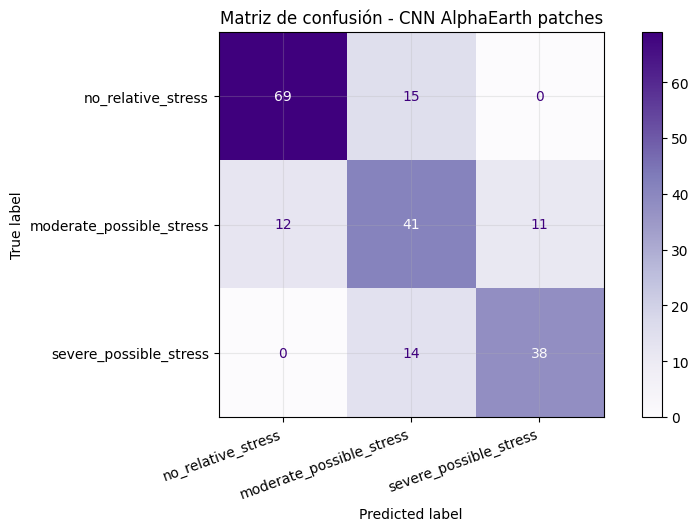

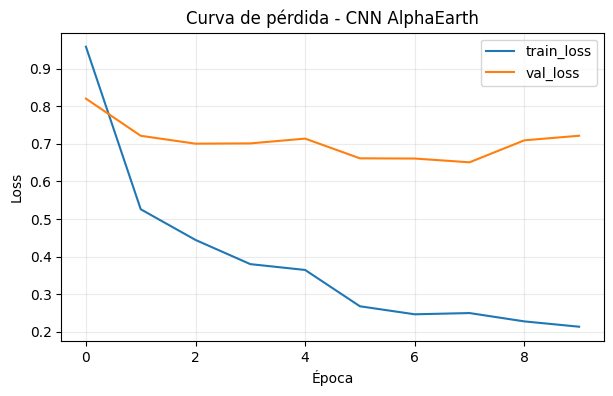

In [18]:
cnn_metrics = None

if RUN_OPTIONAL_CNN and TF_AVAILABLE and TIFFFILE_AVAILABLE and available_patch_mask.sum() >= 30:
    cnn_df = model_df.loc[available_patch_mask].copy()
    cnn_patch_paths = patch_paths.loc[available_patch_mask]

    print("Cargando parches para CNN...")
    try:
        X_patch = np.stack([
            load_alphaearth_patch(path, target_size=PATCH_TARGET_SIZE)
            for path in cnn_patch_paths
        ]).astype("float32")
    except ValueError as exc:
        if "COMPRESSION.LZW" in str(exc) or "imagecodecs" in str(exc):
            raise RuntimeError(
                "Los parches TIFF usan compresión LZW. Instala imagecodecs en el kernel activo: "
                "import sys; !{sys.executable} -m pip install imagecodecs"
            ) from exc
        raise
    y_patch = cnn_df[target_col].astype(int).to_numpy()

    train_mask = cnn_df.index.isin(train_idx)
    test_mask = cnn_df.index.isin(test_idx)

    X_patch_train, X_patch_test = X_patch[train_mask], X_patch[test_mask]
    y_patch_train, y_patch_test = y_patch[train_mask], y_patch[test_mask]

    channel_mean = X_patch_train.mean(axis=(0, 1, 2), keepdims=True)
    channel_std = X_patch_train.std(axis=(0, 1, 2), keepdims=True) + 1e-6
    X_patch_train = (X_patch_train - channel_mean) / channel_std
    X_patch_test = (X_patch_test - channel_mean) / channel_std

    num_classes = len(np.unique(y))
    input_shape = X_patch_train.shape[1:]

    cnn_model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(12, kernel_size=3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(24, kernel_size=3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(48, kernel_size=3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.50),
        layers.Dense(48, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.35),
        layers.Dense(num_classes, activation="softmax"),
    ])

    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_patch_train)
    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)

    start = time.perf_counter()
    history = cnn_model.fit(
        X_patch_train,
        y_patch_train,
        validation_split=0.20,
        epochs=min(CNN_EPOCHS, 10),
        batch_size=CNN_BATCH_SIZE,
        sample_weight=sample_weight,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )
    cnn_fit_seconds = time.perf_counter() - start

    y_prob_cnn = cnn_model.predict(X_patch_test, verbose=0)
    y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

    cnn_metrics = metric_row("cnn_alphaearth_patches_experimental", y_patch_test, y_pred_cnn, cnn_fit_seconds)
    display(pd.DataFrame([cnn_metrics]))

    print(classification_report(
        y_patch_test,
        y_pred_cnn,
        labels=sorted(y.unique()),
        target_names=[label_map.get(c, str(c)) for c in sorted(y.unique())],
        zero_division=0,
    ))

    cm = confusion_matrix(y_patch_test, y_pred_cnn, labels=sorted(y.unique()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_map.get(c, str(c)) for c in sorted(y.unique())])
    disp.plot(cmap="Purples", values_format="d")
    plt.title("Matriz de confusión - CNN AlphaEarth patches")
    plt.xticks(rotation=20, ha="right")
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title("Curva de pérdida - CNN AlphaEarth")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("CNN no ejecutada.")
    print("Requisitos: RUN_OPTIONAL_CNN=True, TensorFlow instalado, tifffile/imagecodecs instalados y parches locales disponibles.")


## 17. Comparación final y elección del modelo individual

La tabla final conserva todos los modelos para transparencia, incluyendo la CNN como experimento complementario. Para la elección del modelo individual final se priorizan los modelos ajustados en la sección de fine-tuning, porque la rúbrica solicita seleccionar los dos mejores modelos, ajustarlos y elegir el modelo final a partir de ese proceso.

La selección toma en cuenta:

- `F1 macro`: métrica principal por desbalance.
- `recall_severo`: importante porque pasar por alto estrés severo tiene mayor costo operativo.
- Estabilidad en validación cruzada.
- Tiempo de entrenamiento.
- Interpretabilidad y complejidad computacional.

La CNN se reporta como evidencia de uso directo de los parches `HxWx64`, pero no desplaza al modelo final si su desempeño es menor.


In [19]:
comparison_parts = [
    results_df.assign(etapa="comparacion_inicial"),
    final_tuned_df.assign(etapa="ajuste_fino"),
]

if "cnn_metrics" in globals() and cnn_metrics is not None:
    comparison_parts.append(pd.DataFrame([cnn_metrics]).assign(etapa="cnn_experimental"))

final_comparison = pd.concat(comparison_parts, ignore_index=True, sort=False)
final_comparison = final_comparison.sort_values(["f1_macro", "balanced_accuracy"], ascending=False)
display(final_comparison)

final_candidates = final_comparison[final_comparison["etapa"].eq("ajuste_fino")].copy()
if final_candidates.empty:
    final_candidates = final_comparison[~final_comparison["modelo"].str.contains("dummy", case=False, na=False)].copy()

best_row = final_candidates.sort_values(["f1_macro", "balanced_accuracy"], ascending=False).iloc[0]
print("Modelo individual final elegido:", best_row["modelo"])
print("F1 macro:", round(best_row["f1_macro"], 4))
print("Balanced accuracy:", round(best_row["balanced_accuracy"], 4))
print("Recall severo:", round(best_row["recall_severo"], 4))
print("Dataset usado:", dataset_version)

if "cnn_metrics" in globals() and cnn_metrics is not None:
    print("\nCNN experimental:")
    print("F1 macro:", round(cnn_metrics["f1_macro"], 4))
    print("Balanced accuracy:", round(cnn_metrics["balanced_accuracy"], 4))
    print("Recall severo:", round(cnn_metrics["recall_severo"], 4))


,modelo,accuracy,f1_macro,f1_weighted,balanced_accuracy,precision_macro,recall_macro,recall_severo,fit_seconds,etapa
0,logistic_regression_balanced,0.815,0.814382,0.816798,0.816239,0.814048,0.816239,0.865385,0.056571,comparacion_inicial
8,rbf_svm_balanced_tuned,0.810,0.813926,0.815810,0.811222,0.839996,0.811222,0.769231,0.029000,ajuste_fino
9,logistic_regression_balanced_tuned,0.790,0.797508,0.794621,0.797676,0.807594,0.797676,0.846154,0.057953,ajuste_fino
1,rbf_svm_balanced,0.790,0.795336,0.796630,0.791667,0.825755,0.791667,0.750000,0.028873,comparacion_inicial
2,mlp_neural_network,0.785,0.787484,0.791345,0.782776,0.813648,0.782776,0.730769,0.132917,comparacion_inicial
10,cnn_alphaearth_patches_experimental,0.740,0.733593,0.742737,0.730941,0.737692,0.730941,0.730769,4.040577,cnn_experimental
3,linear_svm_balanced,0.720,0.723367,0.725498,0.724874,0.729723,0.724874,0.788462,0.410068,comparacion_inicial
4,knn_distance,0.690,0.691546,0.696596,0.685325,0.731947,0.685325,0.596154,0.017277,comparacion_inicial
5,decision_tree_balanced,0.695,0.682773,0.697094,0.673249,0.711174,0.673249,0.557692,0.098427,comparacion_inicial
6,gaussian_naive_bayes,0.625,0.630034,0.631988,0.622692,0.681515,0.622692,0.538462,0.018232,comparacion_inicial


Modelo individual final elegido: rbf_svm_balanced_tuned
F1 macro: 0.8139
Balanced accuracy: 0.8112
Recall severo: 0.7692
Dataset usado: alphaearth_annual_2018_2025

CNN experimental:
F1 macro: 0.7336
Balanced accuracy: 0.7309
Recall severo: 0.7308


## 18. Conclusiones

Se construyeron y compararon modelos individuales sobre un dataset anual AlphaEarth con 100 parcelas entre 2018 y 2025. La unidad de observación fue parcela-año y los predictores principales fueron 512 estadísticos derivados de los 64 canales AlphaEarth. Para evitar fuga conceptual, las variables NDVI/NDMI anuales se reservaron para auditoría de etiquetas y no se usaron como predictores. La evaluación consideró partición por parcela, `F1 macro` como métrica principal, validación cruzada `GroupKFold`, ajuste fino de los dos mejores modelos y selección final basada en desempeño, estabilidad, detección de estrés severo, costo computacional e interpretabilidad.

En la comparación inicial, la regresión logística balanceada obtuvo el mejor desempeño puntual en prueba. Después del ajuste fino, el modelo `rbf_svm_balanced_tuned` quedó como el mejor candidato ajustado, con `F1 macro = 0.8139`, `balanced accuracy = 0.8112` y `recall` para estrés severo de `0.7692`. Por cumplimiento metodológico de la rúbrica, el modelo final se elige entre los modelos ajustados.

La CNN sobre parches AlphaEarth `HxWx64` se incorporó como experimento complementario para evaluar el uso directo de la estructura espacial. En la ejecución final obtuvo `F1 macro = 0.7336`, `balanced accuracy = 0.7309` y `recall` para estrés severo de `0.7308`, por debajo del modelo tabular seleccionado. La curva de pérdida muestra que el entrenamiento mejora de forma más estable que la validación, con separación y fluctuación entre ambas curvas. Esto sugiere sobreajuste moderado o capacidad de generalización limitada, algo esperable con 800 observaciones y una CNN entrenada desde cero.

El modelo final recomendado es `rbf_svm_balanced_tuned`. La CNN se reporta como evidencia de exploración espacial y como línea futura de mejora, no como modelo final.

Limitación importante:

Las etiquetas siguen siendo proxy derivadas de índices espectrales, no mediciones de campo. Por tanto, el desempeño alto indica consistencia con la regla operacional de estrés, pero todavía no equivale a validación agronómica completa.

Siguiente paso recomendado:

Validar las etiquetas con mediciones de campo, probar particiones temporales estrictas y mejorar la CNN mediante más datos, aumentación, regularización o transferencia de aprendizaje sobre los parches AlphaEarth completos.
